# 06 — Interpretation & Evaluation

**Input:** `../data/processed/pm_day_features.csv`, `../data/processed/embeddings.npy`, `../outputs/tables/oof_*.csv`
**Output:** `../outputs/figures/dca_*.png`, `../outputs/tables/topk_eval_all.csv`, `../outputs/tables/pc_exemplars.csv`

**Description:**
- Decision Curve Analysis on OOF predictions
- Precision@K / Recall@K evaluation
- PC exemplar text extraction for interpretation

In [49]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG
# =========================
DATA_PATH = os.path.join("..", "data", "processed", "pm_day_features.csv")
EMBED_PATH = os.path.join("..", "data", "processed", "embeddings.npy")
OOF_DIR = os.path.join("..", "outputs", "tables")
FIG_DIR = os.path.join("..", "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

PID_COL = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
RANDOM_SEED = 7

In [51]:
# =========================
# LOAD
# =========================
pm_day = pd.read_csv(DATA_PATH)
X_text = np.load(EMBED_PATH)
print("Loaded data:", pm_day.shape)

Loaded data: (2511, 73)


In [53]:
# =========================
# DCA FUNCTIONS
# =========================
def net_benefit(y, p, pt):
    y = np.asarray(y).astype(int)
    N = len(y)
    pred_pos = (p >= pt).astype(int)
    TP = int(((pred_pos == 1) & (y == 1)).sum())
    FP = int(((pred_pos == 1) & (y == 0)).sum())
    w = pt / (1.0 - pt)
    return (TP / N) - (FP / N) * w


def treat_all_nb(y, pt):
    prev = np.mean(y)
    w = pt / (1.0 - pt)
    return prev - (1.0 - prev) * w


def run_dca(oof_path, outcome_label):
    df = pd.read_csv(oof_path)
    y = df["y"].astype(int).values
    p_base = df["p_base"].values
    p_full = df["p_full"].values

    pts = np.linspace(0.005, 0.20, 200)
    rows = []
    for pt in pts:
        rows.append({
            "pt": pt,
            "NB_none": 0.0,
            "NB_all": treat_all_nb(y, pt),
            "NB_baseline": net_benefit(y, p_base, pt),
            "NB_full": net_benefit(y, p_full, pt),
        })
    dca = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(dca["pt"], dca["NB_none"], label="Treat none", ls="--", color="gray")
    ax.plot(dca["pt"], dca["NB_all"], label="Treat all", ls="--", color="black")
    ax.plot(dca["pt"], dca["NB_baseline"], label="Baseline (numeric)")
    ax.plot(dca["pt"], dca["NB_full"], label="Full (+text)")
    ax.set_xlabel("Threshold probability")
    ax.set_ylabel("Net benefit")
    ax.set_title(f"Decision Curve: {outcome_label}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"dca_{outcome_label}.png"), dpi=300)
    plt.show()
    return dca

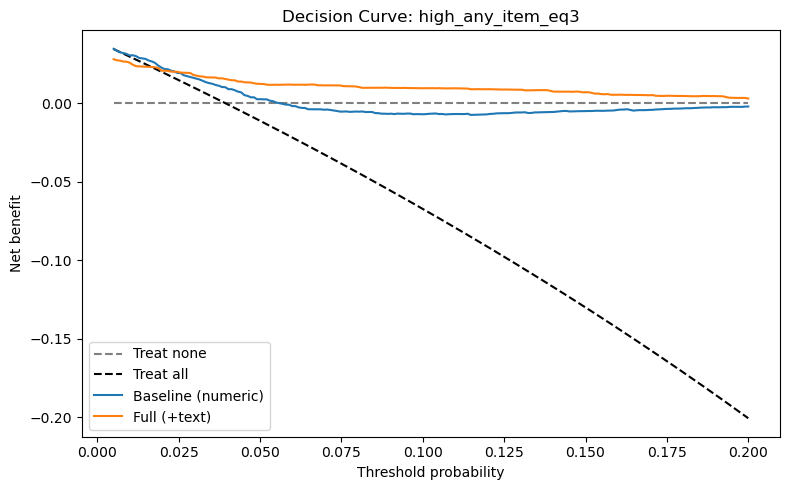

In [55]:
# =========================
# RUN DCA FOR PRIMARY OUTCOME
# =========================
primary_oof = os.path.join(OOF_DIR, "oof_high_any_item_eq3__logit.csv")
if os.path.exists(primary_oof):
    dca = run_dca(primary_oof, "high_any_item_eq3")
else:
    print("OOF file not found. Run notebook 04 first.")

In [57]:
# =========================
# PRECISION@K / RECALL@K
# =========================
def topk_eval(y, probs, top_fracs=(0.01, 0.02, 0.05, 0.10)):
    y = np.asarray(y).astype(int)
    order = np.argsort(-probs)
    rows = []
    for frac in top_fracs:
        k = max(1, int(np.ceil(frac * len(y))))
        idx = order[:k]
        tp = int(y[idx].sum())
        precision = tp / k
        recall = tp / max(1, int(y.sum()))
        rows.append({"top_frac": frac, "k_days": k, "precision": precision, "recall": recall})
    return pd.DataFrame(rows)

all_topk = []
for f in sorted(os.listdir(OOF_DIR)):
    if f.startswith("oof_") and f.endswith(".csv"):
        df = pd.read_csv(os.path.join(OOF_DIR, f))
        label = f.replace("oof_", "").replace(".csv", "")
        for model_col, model_name in [("p_base", "baseline"), ("p_full", "full")]:
            tk = topk_eval(df["y"].values, df[model_col].values)
            tk["label"] = label
            tk["model"] = model_name
            all_topk.append(tk)

if all_topk:
    topk_all = pd.concat(all_topk, ignore_index=True)
    topk_path = os.path.join(OOF_DIR, "topk_eval_all.csv")
    topk_all.to_csv(topk_path, index=False)
    print("Saved top-K evaluation:", topk_path)

Saved top-K evaluation: ../outputs/tables/topk_eval_all.csv


In [59]:
# =========================
# PC EXEMPLAR TEXT EXTRACTION (all 5 interpretive PCs)
# =========================
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)


def anonymize_text(s):
    s = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "[EMAIL]", s)
    s = re.sub(r"https?://\S+|www\.\S+", "[URL]", s)
    s = re.sub(r"\d", "X", s)
    return re.sub(r"\s+", " ", s).strip()


X_norm = l2_normalize_rows(X_text)
X_z = StandardScaler().fit_transform(X_norm)
pca = PCA(n_components=5, random_state=RANDOM_SEED)
T = pca.fit_transform(X_z)

# Create columns for all 5 PCs and decompose within/between
for k in range(5):
    col = f"_PC{k+1}"
    pm_day[col] = T[:, k]
    pm_day[f"{col}_between"] = pm_day.groupby(PID_COL)[col].transform("mean")
    pm_day[f"{col}_within"] = pm_day[col] - pm_day[f"{col}_between"]

pm_day["_wc"] = pm_day[TEXT_COL].fillna("").astype(str).str.split().map(len)


def get_exemplars(df, score_col, direction="high", n=3, min_words=6):
    df = df[df["_wc"] >= min_words].copy()
    df = df.sort_values(score_col, ascending=(direction != "high")).head(50)
    seen = set()
    chosen = []
    for _, row in df.iterrows():
        pid = str(row[PID_COL])
        if pid in seen:
            continue
        seen.add(pid)
        chosen.append({
            "pc": score_col,
            "direction": direction,
            "score": row[score_col],
            "text": anonymize_text(str(row[TEXT_COL]))
        })
        if len(chosen) >= n:
            break
    return chosen


# Extract exemplars for all 5 PCs (within-person)
exemplars = []
for k in range(1, 6):
    pc_col = f"_PC{k}_within"
    exemplars += get_exemplars(pm_day, pc_col, "high")
    exemplars += get_exemplars(pm_day, pc_col, "low")

ex_df = pd.DataFrame(exemplars)
ex_path = os.path.join(OOF_DIR, "pc_exemplars_all5.csv")
ex_df.to_csv(ex_path, index=False)
print(f"Saved {len(ex_df)} exemplars to: {ex_path}")

# Print for review
for k in range(1, 6):
    pc_col = f"_PC{k}_within"
    sub = ex_df[ex_df["pc"] == pc_col]
    print(f"\n{'='*60}")
    print(f"PC{k} (within-person)")
    print(f"{'='*60}")
    for _, row in sub.iterrows():
        tag = "HIGH" if row["direction"] == "high" else "LOW"
        print(f"  [{tag}] score={row['score']:.3f}")
        print(f"    {row['text'][:200]}")
        print()

Saved 30 exemplars to: ../outputs/tables/pc_exemplars_all5.csv

PC1 (within-person)
  [HIGH] score=18.559
    I have so much unknown in my life. Where will I live in a few months? What can I afford? Can I pack everything up without losing myself in the process. I need help but I'm mostly doing it alone. Its h

  [HIGH] score=17.842
    I don't want to be around anyone. I'm not interested in socializing or interacting with anyone. I would rather stay to myself. I'm feeling alone and stuck in a situation. I don't see the light at the 

  [HIGH] score=16.136
    I’m sad because I’ve been ghosted by someone I was interested in. I was thinking a lot on my drive home. Today I tried a new exercise class so I was excited about that. I’m tired of putting more effor

  [LOW] score=-18.943
    Today was fairly good, I think I read a book I have been trying to read for a year. Sometimes I wish life was like a book, you could pick it up anytime and it would always make sense.i felt I had more

  [L